<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Monte_Carlo_Prediction_of_the_First_Trillionaire_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Mean projected year: 2146.9
Median projected year: 2139.1
Central 90% scenario interval: 2106.6 to 2213.7


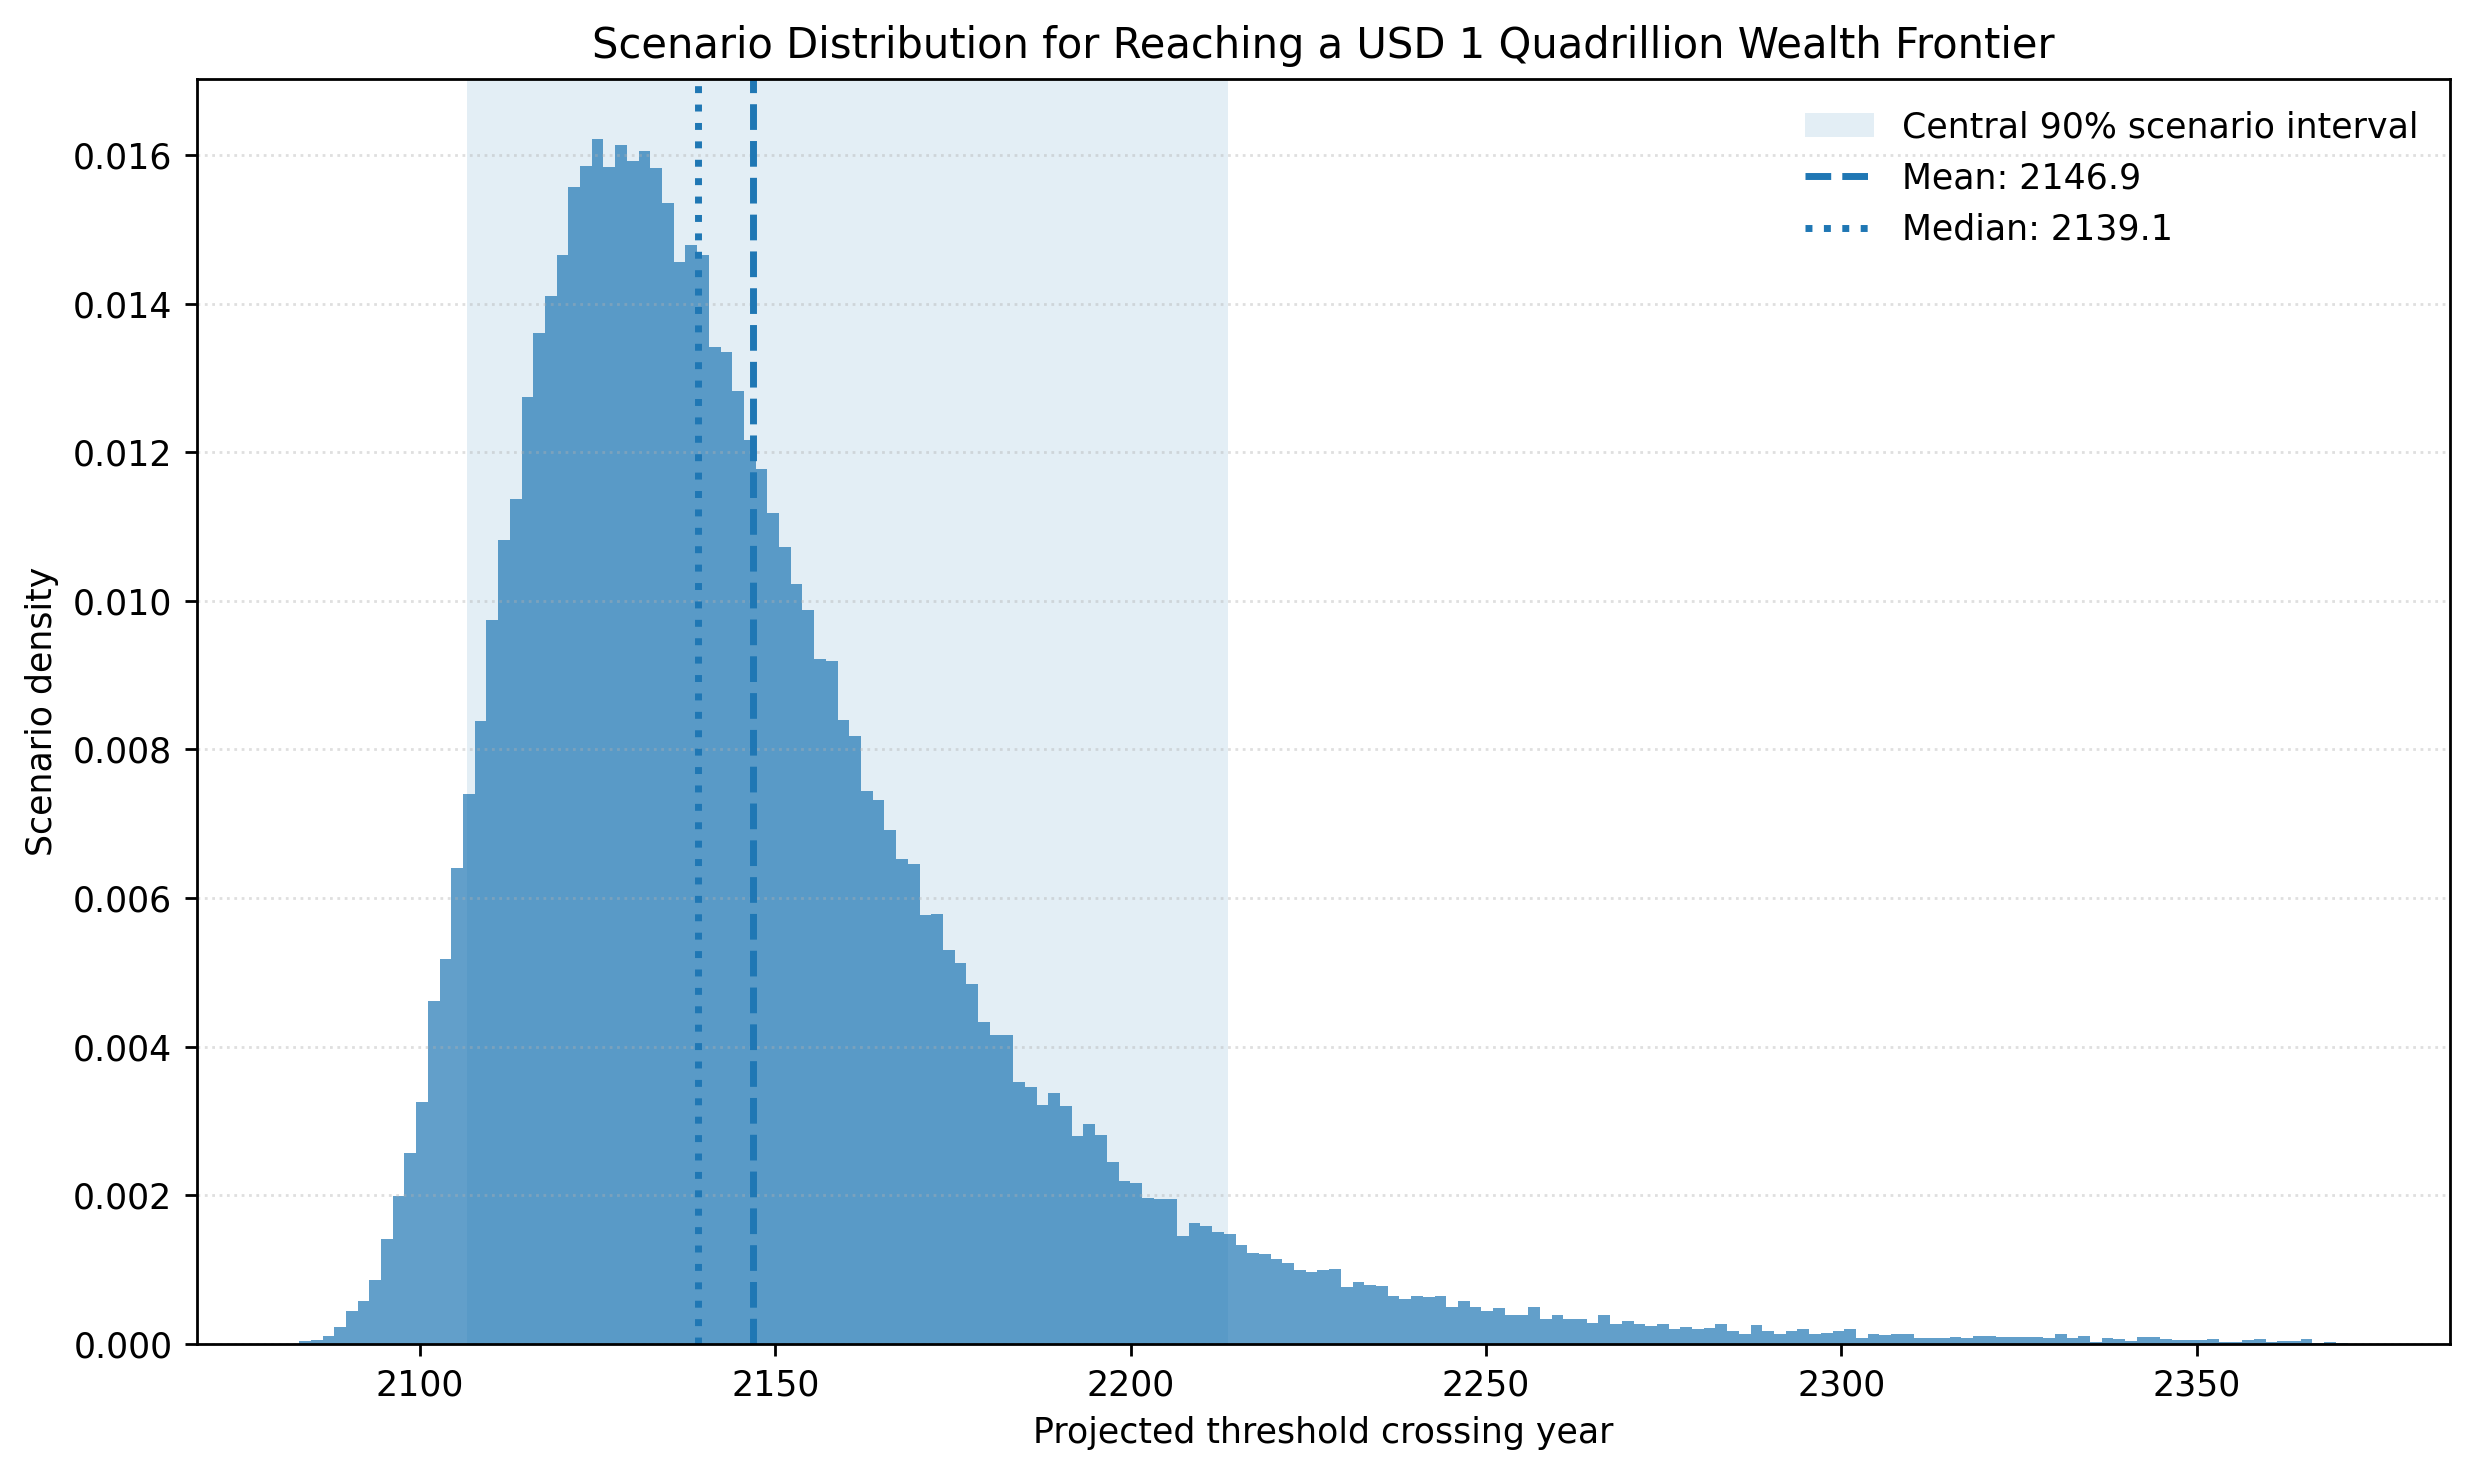

In [ ]:
"""Project when an extreme wealth frontier crosses a selected threshold.

Each realization samples one constant continuously compounded annual growth
rate for the maximum observed individual net worth and converts that rate into
a threshold crossing year. The resulting distribution quantifies uncertainty
conditional on the selected assumptions. It remains separate from a causal
economic forecast, an annual wealth trajectory, or a population extreme value
model.
"""

from dataclasses import dataclass
from typing import Final

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt

# Colab installation command
# !uv pip install -q numpy matplotlib

# Control knobs for rendering and interval reporting
FIGURE_DPI: Final[int] = 250
FIGURE_SIZE: Final[tuple[float, float]] = (10.0, 6.0)
LOWER_QUANTILE: Final[float] = 0.05
UPPER_QUANTILE: Final[float] = 0.95

FloatArray = npt.NDArray[np.float64]


@dataclass(frozen=True, slots=True)
class ProjectionConfig:
    """Store the assumptions governing the scenario projection."""

    start_year: int = 2026
    start_wealth_usd: float = 1.0e12
    target_wealth_usd: float = 1.0e15

    # Continuously compounded annual log growth rate in inverse years.
    mean_log_growth_rate: float = 0.061

    # Uncertainty across long term growth scenarios.
    log_growth_rate_std: float = 0.015
    min_log_growth_rate: float = 0.020
    max_log_growth_rate: float = 0.150

    num_simulations: int = 100_000
    random_seed: int | None = 2026

    def validate(self) -> None:
        """Raise an exception when assumptions are internally inconsistent."""
        if self.start_wealth_usd <= 0.0:
            raise ValueError("start_wealth_usd must be positive.")

        if self.target_wealth_usd <= self.start_wealth_usd:
            raise ValueError(
                "target_wealth_usd must exceed start_wealth_usd."
            )

        if self.log_growth_rate_std <= 0.0:
            raise ValueError("log_growth_rate_std must be positive.")

        if not (
            0.0
            < self.min_log_growth_rate
            < self.mean_log_growth_rate
            < self.max_log_growth_rate
        ):
            raise ValueError(
                "Growth rate bounds must satisfy "
                "0 < minimum < mean < maximum."
            )

        if self.num_simulations < 1:
            raise ValueError("num_simulations must be at least one.")


@dataclass(frozen=True, slots=True)
class ProjectionResult:
    """Contain sampled rates and their implied crossing years."""

    growth_rates: FloatArray
    projected_years: FloatArray


@dataclass(frozen=True, slots=True)
class ProjectionSummary:
    """Contain central statistics for the simulated crossing years."""

    mean_year: float
    median_year: float
    lower_year: float
    upper_year: float


def sample_truncated_normal(
    rng: np.random.Generator,
    mean: float,
    standard_deviation: float,
    lower_bound: float,
    upper_bound: float,
    size: int,
) -> FloatArray:
    """Draw bounded normal samples without accumulating mass at the bounds."""
    samples = rng.normal(
        loc=mean,
        scale=standard_deviation,
        size=size,
    ).astype(
        np.float64,
        copy=False,
    )

    invalid = (samples < lower_bound) | (samples > upper_bound)

    while np.any(invalid):
        number_invalid = int(np.count_nonzero(invalid))

        samples[invalid] = rng.normal(
            loc=mean,
            scale=standard_deviation,
            size=number_invalid,
        )

        invalid = (samples < lower_bound) | (samples > upper_bound)

    return samples


def execute_monte_carlo_projection(
    config: ProjectionConfig,
) -> ProjectionResult:
    """Convert sampled long term growth rates into crossing years."""
    config.validate()
    rng = np.random.default_rng(config.random_seed)

    growth_rates = sample_truncated_normal(
        rng=rng,
        mean=config.mean_log_growth_rate,
        standard_deviation=config.log_growth_rate_std,
        lower_bound=config.min_log_growth_rate,
        upper_bound=config.max_log_growth_rate,
        size=config.num_simulations,
    )

    log_wealth_ratio = np.log(
        config.target_wealth_usd / config.start_wealth_usd
    )
    years_to_target = log_wealth_ratio / growth_rates
    projected_years = config.start_year + years_to_target

    return ProjectionResult(
        growth_rates=growth_rates,
        projected_years=projected_years,
    )


def summarize_projection(
    result: ProjectionResult,
) -> ProjectionSummary:
    """Calculate the mean, median, and central scenario interval."""
    lower_year, median_year, upper_year = np.quantile(
        result.projected_years,
        [LOWER_QUANTILE, 0.50, UPPER_QUANTILE],
    )

    return ProjectionSummary(
        mean_year=float(np.mean(result.projected_years)),
        median_year=float(median_year),
        lower_year=float(lower_year),
        upper_year=float(upper_year),
    )


def print_projection_summary(
    summary: ProjectionSummary,
) -> None:
    """Print an interpretable summary of the simulated crossing years."""
    interval_percentage = 100.0 * (
        UPPER_QUANTILE - LOWER_QUANTILE
    )

    print(f"Mean projected year: {summary.mean_year:.1f}")
    print(f"Median projected year: {summary.median_year:.1f}")
    print(
        f"Central {interval_percentage:.0f}% scenario interval: "
        f"{summary.lower_year:.1f} to {summary.upper_year:.1f}"
    )


def render_distribution_plot(
    result: ProjectionResult,
    summary: ProjectionSummary,
) -> None:
    """Render the distribution using local plotting configuration."""
    plot_settings = {
        "font.sans-serif": ["Tahoma", "DejaVu Sans"],
        "font.weight": "normal",
        "figure.dpi": FIGURE_DPI,
    }

    with plt.rc_context(plot_settings):
        fig, ax = plt.subplots(figsize=FIGURE_SIZE)

        ax.hist(
            result.projected_years,
            bins="fd",
            density=True,
            alpha=0.70,
        )

        ax.axvspan(
            summary.lower_year,
            summary.upper_year,
            alpha=0.12,
            label="Central 90% scenario interval",
        )

        ax.axvline(
            summary.mean_year,
            linestyle="--",
            linewidth=2.0,
            label=f"Mean: {summary.mean_year:.1f}",
        )

        ax.axvline(
            summary.median_year,
            linestyle=":",
            linewidth=2.0,
            label=f"Median: {summary.median_year:.1f}",
        )

        ax.set_title(
            "Scenario Distribution for Reaching a "
            "USD 1 Quadrillion Wealth Frontier"
        )
        ax.set_xlabel("Projected threshold crossing year")
        ax.set_ylabel("Scenario density")
        ax.grid(
            axis="y",
            linestyle=":",
            alpha=0.40,
        )
        ax.legend(frameon=False)

        fig.tight_layout()
        plt.show()


def main() -> None:
    """Execute the projection, report statistics, and render the result."""
    config = ProjectionConfig()
    result = execute_monte_carlo_projection(config)
    summary = summarize_projection(result)

    print_projection_summary(summary)
    render_distribution_plot(result, summary)


if __name__ == "__main__":
    main()